# Fine-Tuning DistilBERT for AG News Text Classification

**Student Identity**

- Name: Haikal Ali
- Class: TK-46-GAB
- NIM: 1103223071

## Project Summary

This notebook implements an end-to-end Transformer fine-tuning pipeline for multi-class text classification using HuggingFace Transformers.

The model used in this project is `distilbert-base-uncased`, a BERT-family encoder model.  
The dataset used is `AG News`, which contains news articles categorized into four classes:

1. World
2. Sports
3. Business
4. Sci/Tech

## Pipeline

1. Environment setup
2. Dataset loading
3. Exploratory data analysis
4. Data splitting and sampling
5. Tokenization
6. Model preparation
7. Fine-tuning
8. Evaluation
9. Error analysis
10. Inference
11. Saving outputs and report

## 1. Environment Setup

This section installs and imports the required libraries.

The notebook is designed to run on Google Colab.  
Runtime recommendation: **GPU / T4**.

In [1]:
!pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib

In [2]:
# Hard fix for Colab torchvision / HuggingFace datasets conflict
# Prevent datasets TorchFormatter from trying to import torchvision.io.VideoReader

import sys
import os

os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"

try:
  import datasets.config
  datasets.config.TORCHVISION_AVAILABLE = False
except Exception as e:
  print("datasets.config patch skipped:", e)

if "torchvision" in sys.modules:
  del sys.modules["torchvision"]

print("Torchvision conflict patch applied.")

Torchvision conflict patch applied.


In [3]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
  AutoTokenizer,
  AutoModelForSequenceClassification,
  DataCollatorWithPadding,
  TrainingArguments,
  Trainer,
  set_seed
)

from sklearn.metrics import (
  accuracy_score,
  precision_recall_fscore_support,
  classification_report,
  confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

OUTPUT_DIR = Path("outputs")
REPORT_DIR = Path("reports")
MODEL_DIR = Path("models/distilbert-ag-news")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {device}")

if device == "cuda":
  print(f"GPU: {torch.cuda.get_device_name(0)}")
  print(f"CUDA available: {torch.cuda.is_available()}")
else:
  print("GPU is not available. Training will be slower on CPU.")

Device: cpu
GPU is not available. Training will be slower on CPU.


## 2. Load Dataset

The dataset used in this notebook is **AG News** from HuggingFace Datasets.

AG News is a multi-class text classification dataset where each article is assigned to one of four topic categories.

In [4]:
from datasets import load_dataset

DATASET_NAME = "sh0416/ag_news"

# The finalterm PDF references sh0416/ag_news. This repo uses raw labels 1-4
# and separate title/description fields, so the next cells normalize it.
dataset = load_dataset(DATASET_NAME)

print(dataset)
print("\nAvailable splits:", list(dataset.keys()))
print("Train samples:", len(dataset["train"]))
print("Test samples:", len(dataset["test"]))
print("\nColumns:", dataset["train"].column_names)
print("\nFirst raw sample:")
print(dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

Available splits: ['train', 'test']
Train samples: 120000
Test samples: 7600

Columns: ['label', 'title', 'description']

First raw sample:
{'label': 3, 'title': 'Wall St. Bears Claw Back Into the Black (Reuters)', 'description': "Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."}


In [5]:
raw_labels = sorted(set(int(x) for x in dataset["train"]["label"]))
print("Raw labels from dataset:", raw_labels)

# AG News canonical classes.
canonical_label_names = ["World", "Sports", "Business", "Sci/Tech"]

if raw_labels == [1, 2, 3, 4]:
  raw_id2label = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
  }
  raw_label_to_model_label = {
    1: 0,
    2: 1,
    3: 2,
    4: 3
  }
elif raw_labels == [0, 1, 2, 3]:
  raw_id2label = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
  }
  raw_label_to_model_label = {
    0: 0,
    1: 1,
    2: 2,
    3: 3
  }
else:
  raise ValueError(f"Unexpected AG News label format: {raw_labels}")

# Model labels must be zero-based: 0, 1, 2, 3.
label_names = canonical_label_names
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in id2label.items()}

print("\nRaw label mapping:")
for raw_id, label in raw_id2label.items():
  print(f"{raw_id}: {label} -> model label {raw_label_to_model_label[raw_id]}")

print("\nModel label mapping:")
for model_id, label in id2label.items():
  print(f"{model_id}: {label}")

Raw labels from dataset: [1, 2, 3, 4]

Raw label mapping:
1: World -> model label 0
2: Sports -> model label 1
3: Business -> model label 2
4: Sci/Tech -> model label 3

Model label mapping:
0: World
1: Sports
2: Business
3: Sci/Tech


## 3. Exploratory Data Analysis

Before fine-tuning the model, the dataset is inspected to understand:

- Label distribution
- Example texts per class
- Approximate text length distribution

This is important because a complete deep learning workflow should not jump directly into training.

In [6]:
train_df_preview = pd.DataFrame(dataset["train"].select(range(10)))
train_df_preview["raw_label_name"] = train_df_preview["label"].map(lambda x: raw_id2label[int(x)])
train_df_preview["model_label_id"] = train_df_preview["label"].map(lambda x: raw_label_to_model_label[int(x)])
train_df_preview["text_preview"] = train_df_preview["title"].fillna("") + ". " + train_df_preview["description"].fillna("")
train_df_preview[["label", "raw_label_name", "model_label_id", "title", "description", "text_preview"]]

,label,raw_label_name,model_label_id,title,description,text_preview
0,3,Business,2,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Business,2,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Business,2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Business,2,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,Business,2,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."
5,3,Business,2,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...,"Stocks End Up, But Near Year Lows (Reuters). R..."
6,3,Business,2,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...,Money Funds Fell in Latest Week (AP). AP - Ass...
7,3,Business,2,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...,Fed minutes show dissent over inflation (USATO...
8,3,Business,2,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...,Safety Net (Forbes.com). Forbes.com - After ea...
9,3,Business,2,Wall St. Bears Claw Back Into the Black,"NEW YORK (Reuters) - Short-sellers, Wall Stre...",Wall St. Bears Claw Back Into the Black. NEW ...


In [7]:
label_counts = pd.Series(dataset["train"]["label"]).value_counts().sort_index()

label_distribution = pd.DataFrame({
  "raw_label_id": label_counts.index,
  "model_label_id": [raw_label_to_model_label[int(i)] for i in label_counts.index],
  "label_name": [raw_id2label[int(i)] for i in label_counts.index],
  "count": label_counts.values
})

label_distribution

,raw_label_id,model_label_id,label_name,count
0,1,0,World,30000
1,2,1,Sports,30000
2,3,2,Business,30000
3,4,3,Sci/Tech,30000


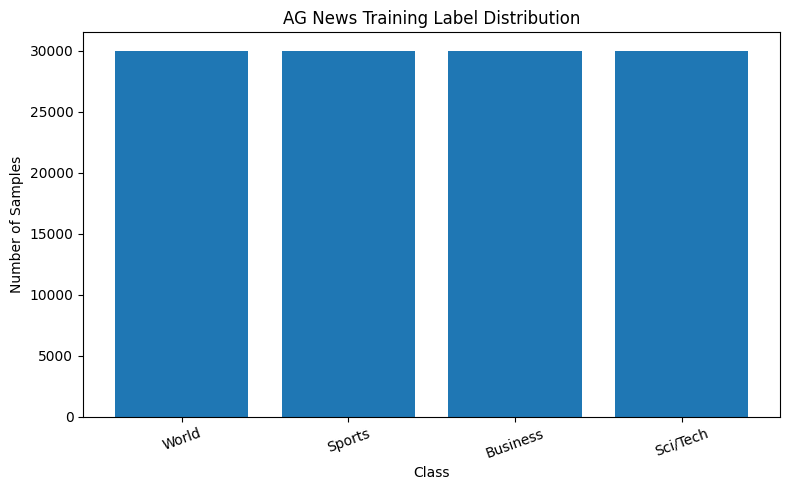

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(label_distribution["label_name"], label_distribution["count"])
plt.title("AG News Training Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "label_distribution.png", dpi=150)
plt.show()

In [9]:
def combine_title_description(example):
  title = example.get("title") or ""
  description = example.get("description") or ""
  raw_label = int(example["label"])

  example["text"] = f"{title}. {description}".strip()
  example["labels"] = raw_label_to_model_label[raw_label]

  return example

# ds is the cleaned dataset used for EDA, tokenization, training, and evaluation.
ds = dataset.map(combine_title_description)

print(ds)
print("\nCleaned columns:", ds["train"].column_names)
print("\nFirst cleaned sample:")
print(ds["train"][0])

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description', 'text', 'labels'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description', 'text', 'labels'],
        num_rows: 7600
    })
})

Cleaned columns: ['label', 'title', 'description', 'text', 'labels']

First cleaned sample:
{'label': 3, 'title': 'Wall St. Bears Claw Back Into the Black (Reuters)', 'description': "Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'text': "Wall St. Bears Claw Back Into the Black (Reuters). Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'labels': 2}


In [10]:
shown_labels = set()

for example in ds["train"]:
  model_label_id = example["labels"]

  if model_label_id not in shown_labels:
    shown_labels.add(model_label_id)

    print("=" * 80)
    print(f"Class ID: {model_label_id}")
    print(f"Class: {id2label[model_label_id]}")
    print(example["text"][:600])

  if len(shown_labels) == len(id2label):
    break

Class ID: 2
Class: Business
Wall St. Bears Claw Back Into the Black (Reuters). Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Class ID: 3
Class: Sci/Tech
'Madden,' 'ESPN' Football Score in Different Ways (Reuters). Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because "Madden NFL 2005" came out that day,\and some fans of the football simulation are rabid enough to\take a sick day to play it.
Class ID: 1
Class: Sports
Phelps, Thorpe Advance in 200 Freestyle (AP). AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's 400 freestyle relay final. Phelps' rivals Ian Thorpe and Pieter van den Hoogenband and teammate Klete Keller were faster than the teenager in the 200 free preliminaries.
Class ID: 0
Class: World
Venezuelans Vote Early in Referendum on Cha

count    3000.000000
mean       37.672000
std         9.791444
min        11.000000
50%        37.000000
75%        43.000000
90%        48.000000
95%        53.000000
99%        68.000000
max       127.000000
dtype: float64


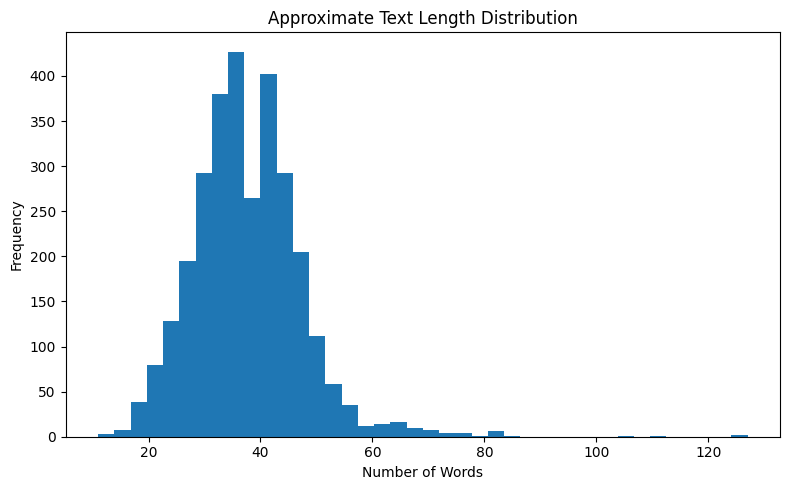

In [11]:
sample_size = min(3000, len(ds["train"]))

sample_for_length = ds["train"].shuffle(seed=SEED).select(range(sample_size))

text_lengths = [
  len(str(text).split())
  for text in sample_for_length["text"]
]

length_stats = pd.Series(text_lengths).describe(
  percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

print(length_stats)

plt.figure(figsize=(8, 5))
plt.hist(text_lengths, bins=40)
plt.title("Approximate Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "text_length_distribution.png", dpi=150)
plt.show()

## 4. Sampling Strategy

The full AG News dataset is large enough for proper training, but this assignment is intended to run in a limited Colab environment.

To keep training realistic and reproducible, this notebook uses a controlled subset:

- Training set: 8,000 samples
- Validation set: 1,000 samples
- Test set: 1,000 samples

The subset is shuffled using a fixed seed to keep the experiment reproducible.

In [12]:
REQUESTED_TRAIN_SIZE = 8000
REQUESTED_VAL_SIZE = 1000
REQUESTED_TEST_SIZE = 1000

available_train = len(ds["train"])
available_test = len(ds["test"])

TRAIN_SIZE = min(REQUESTED_TRAIN_SIZE, max(1, available_train - 1))
VAL_SIZE = min(REQUESTED_VAL_SIZE, max(1, available_train - TRAIN_SIZE))
TEST_SIZE = min(REQUESTED_TEST_SIZE, available_test)

if TRAIN_SIZE + VAL_SIZE > available_train:
  raise ValueError("Train + validation size is larger than the available training split.")

shuffled_train = ds["train"].shuffle(seed=SEED)

train_dataset = shuffled_train.select(range(TRAIN_SIZE))
val_dataset = shuffled_train.select(range(TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE))
test_dataset = ds["test"].shuffle(seed=SEED).select(range(TEST_SIZE))

print("Final dataset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nTrain columns:", train_dataset.column_names)
print("First train sample keys:", train_dataset[0].keys())

Final dataset sizes:
Train: 8000
Validation: 1000
Test: 1000

Train columns: ['label', 'title', 'description', 'text', 'labels']
First train sample keys: dict_keys(['label', 'title', 'description', 'text', 'labels'])


## 5. Tokenization

Transformer models do not directly process raw text.  
The raw text must be converted into numerical token IDs.

This notebook uses the tokenizer from `distilbert-base-uncased`.

Dynamic padding is used through `DataCollatorWithPadding`, so padding is applied per batch instead of padding all samples to the same fixed length.

In [13]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 192

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Model:", MODEL_NAME)
print("Tokenizer vocabulary size:", tokenizer.vocab_size)
print("Maximum model length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Model: distilbert-base-uncased
Tokenizer vocabulary size: 30522
Maximum model length: 512


In [14]:
# Tokenization demonstration using raw preprocessed dataset.
# Use ds instead of train_dataset because train_dataset may already be tokenized
# and may no longer contain the original "text" column.

sample_text = ds["train"][0]["text"]

tokenized_sample = tokenizer(
  sample_text,
  truncation=True,
  max_length=MAX_LENGTH
)

print("Original text:")
print(sample_text)

print("\nTokenized keys:", tokenized_sample.keys())
print("Number of tokens:", len(tokenized_sample["input_ids"]))

print("\nFirst 20 token IDs:")
print(tokenized_sample["input_ids"][:20])

print("\nFirst 20 tokens:")
print(tokenizer.convert_ids_to_tokens(tokenized_sample["input_ids"][:20]))

Original text:
Wall St. Bears Claw Back Into the Black (Reuters). Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Tokenized keys: KeysView({'input_ids': [101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 1012, 26665, 1011, 2460, 1011, 19041, 1010, 2813, 2395, 1005, 1055, 1040, 11101, 2989, 1032, 2316, 1997, 11087, 1011, 22330, 8713, 2015, 1010, 2024, 3773, 2665, 2153, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]})
Number of tokens: 42

First 20 token IDs:
[101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 1012, 26665, 1011, 2460, 1011, 19041, 1010]

First 20 tokens:
['[CLS]', 'wall', 'st', '.', 'bears', 'claw', 'back', 'into', '

In [15]:
!pip install av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 19.7 MB/s eta 0:00:00


In [16]:
!pip show torch torchvision

Name: torch
Version: 2.11.0+cpu
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision
---
Name: torchvision
Version: 0.26.0+cpu
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pillow, torch
Required-by: fastai, timm


In [17]:
def tokenize_batch(batch):
  return tokenizer(
    batch["text"],
    truncation=True,
    max_length=MAX_LENGTH
  )

def tokenize_and_prepare(split_dataset):
  tokenized = split_dataset.map(tokenize_batch, batched=True)

  # Remove raw string/non-model columns so the data collator only receives tensors.
  columns_to_remove = [
    col for col in ["label", "title", "description", "text"]
    if col in tokenized.column_names
  ]
  tokenized = tokenized.remove_columns(columns_to_remove)
  tokenized.set_format("torch")

  return tokenized

tokenized_train = tokenize_and_prepare(train_dataset)
tokenized_val = tokenize_and_prepare(val_dataset)
tokenized_test = tokenize_and_prepare(test_dataset)

print(tokenized_train)
print("Columns:", tokenized_train.column_names)

preview_sample = tokenized_train.with_format(None)[0]

print("First tokenized sample keys:", preview_sample.keys())
print("Label:", preview_sample["labels"])
print("Input IDs length:", len(preview_sample["input_ids"]))
print("Attention mask length:", len(preview_sample["attention_mask"]))

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8000
})
Columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
First tokenized sample keys: dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])


## 6. Load Pre-trained Model

This project uses `distilbert-base-uncased`.

DistilBERT is selected because it is a lighter BERT-family encoder model.  
It is faster and more memory-efficient than full BERT, while still being suitable for text classification tasks.

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
  MODEL_NAME,
  num_labels=len(label_names),
  id2label=id2label,
  label2id=label2id
)

model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {100 * trainable_params / total_params:.2f}%")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 66,956,548
Trainable parameters: 66,956,548
Trainable percentage: 100.00%


## 7. Evaluation Metrics

For multi-class classification, this notebook uses:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted F1

Macro F1 is used as the main metric because it treats all classes equally.

In [19]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)

  accuracy = accuracy_score(labels, predictions)
  precision, recall, macro_f1, _ = precision_recall_fscore_support(
    labels,
    predictions,
    average="macro",
    zero_division=0
  )
  _, _, weighted_f1, _ = precision_recall_fscore_support(
    labels,
    predictions,
    average="weighted",
    zero_division=0
  )

  return {
    "accuracy": accuracy,
    "macro_precision": precision,
    "macro_recall": recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1
  }

## 8. Training Configuration

The model is fine-tuned with a small learning rate, weight decay, warmup, and mixed precision when GPU is available.

The best checkpoint is selected based on validation Macro F1.

In [21]:
import inspect

training_args_kwargs = {
  "output_dir": "checkpoints/distilbert-ag-news",
  "num_train_epochs": 2,
  "per_device_train_batch_size": 16,
  "per_device_eval_batch_size": 32,
  "learning_rate": 2e-5,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "save_strategy": "epoch",
  "logging_strategy": "steps",
  "logging_steps": 50,
  "load_best_model_at_end": True,
  "metric_for_best_model": "macro_f1",
  "greater_is_better": True,
  "report_to": "none",
  "fp16": torch.cuda.is_available(),
  "seed": SEED
}

# Transformers versions differ: some use evaluation_strategy, newer versions expose eval_strategy.
training_args_signature = inspect.signature(TrainingArguments.__init__)
if "eval_strategy" in training_args_signature.parameters:
  training_args_kwargs["eval_strategy"] = "epoch"
else:
  training_args_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_args_kwargs)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
  model=model,
  args=training_args,
  train_dataset=tokenized_train,
  eval_dataset=tokenized_val,
  data_collator=data_collator,
  compute_metrics=compute_metrics
)

print("Trainer is ready.")
print("Evaluation strategy:", getattr(training_args, "eval_strategy", getattr(training_args, "evaluation_strategy", None)))

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer is ready.
Evaluation strategy: IntervalStrategy.EPOCH


## 9. Baseline Evaluation Before Fine-tuning

The classifier head is randomly initialized before training.  
This baseline evaluation shows the model's performance before task-specific fine-tuning.

In [22]:
baseline_metrics = trainer.evaluate(eval_dataset=tokenized_val)

print("Baseline validation metrics:")
for key, value in baseline_metrics.items():
  if isinstance(value, float):
    print(f"{key}: {value:.4f}")
  else:
    print(f"{key}: {value}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
No log,1.385748,0,0.234000,0.354966,0.243368,0.141288,0.138456


Baseline validation metrics:
eval_loss: 1.3857
eval_accuracy: 0.2340
eval_macro_precision: 0.3550
eval_macro_recall: 0.2434
eval_macro_f1: 0.1413
eval_weighted_f1: 0.1385


## 10. Fine-tuning

The model is fine-tuned on the AG News training subset.

In [23]:
train_result = trainer.train()

print("Training finished.")
print(train_result.metrics)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,0.298940,0.372841,0.889000,0.891677,0.892384,0.889117,0.887913
2,0.230387,0.322711,0.907000,0.908308,0.909183,0.907594,0.906905


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished.
{'train_runtime': 8563.5572, 'train_samples_per_second': 1.868, 'train_steps_per_second': 0.117, 'total_flos': 405232225456128.0, 'train_loss': 0.3582694158554077, 'epoch': 2.0}


## 11. Final Evaluation on Test Set

After training, the model is evaluated on a separate test subset that was not used during training or validation.

In [24]:
test_predictions = trainer.predict(tokenized_test)

test_logits = test_predictions.predictions
y_true = test_predictions.label_ids
y_pred = np.argmax(test_logits, axis=-1)

test_metrics = compute_metrics((test_logits, y_true))
test_metrics = {key: float(value) for key, value in test_metrics.items()}

print("Final test metrics:")
for key, value in test_metrics.items():
  print(f"{key}: {value:.4f}")

with open(OUTPUT_DIR / "metrics.json", "w") as f:
  json.dump(test_metrics, f, indent=2)

print("\nSaved metrics to outputs/metrics.json")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Final test metrics:
accuracy: 0.9090
macro_precision: 0.9115
macro_recall: 0.9100
macro_f1: 0.9089
weighted_f1: 0.9090

Saved metrics to outputs/metrics.json


In [25]:
print("Classification Report:")
report_text = classification_report(
  y_true,
  y_pred,
  target_names=label_names,
  digits=4,
  zero_division=0
)

print(report_text)

with open(OUTPUT_DIR / "classification_report.txt", "w") as f:
  f.write(report_text)

Classification Report:
              precision    recall  f1-score   support

       World     0.9623    0.8647    0.9109       266
      Sports     0.9683    0.9919    0.9799       246
    Business     0.8922    0.8415    0.8661       246
    Sci/Tech     0.8231    0.9421    0.8786       242

    accuracy                         0.9090      1000
   macro avg     0.9115    0.9100    0.9089      1000
weighted avg     0.9129    0.9090    0.9090      1000



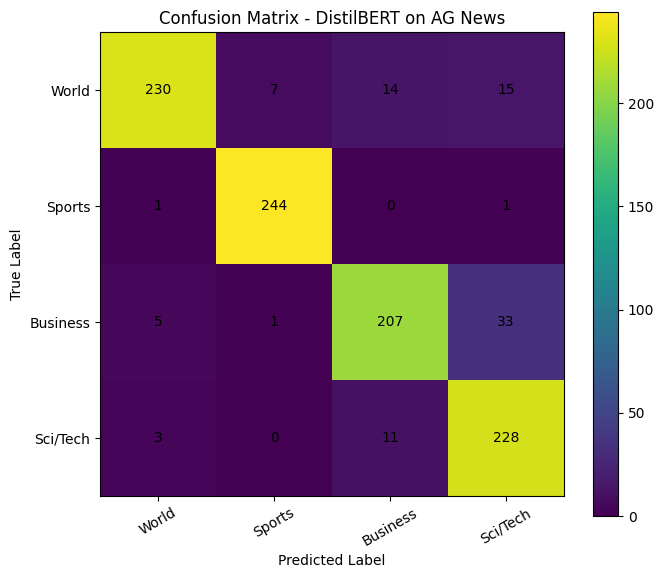

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix - DistilBERT on AG News")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(label_names)), label_names, rotation=30)
plt.yticks(range(len(label_names)), label_names)

for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 12. Training History Visualization

This section visualizes training loss, validation loss, and validation Macro F1.

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_model_preparation_time,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_weighted_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
18,0.247942,6.073349,2.244444e-06,1.8,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,0.185049,0.243423,1.133333e-06,1.9,950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,0.230387,7.608218,2.222222e-08,2.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,NaN,NaN,NaN,2.0,1000,0.322711,0.0091,0.907,0.908308,0.909183,0.907594,0.906905,183.5453,5.448,0.174,NaN,NaN,NaN,NaN,NaN
22,NaN,NaN,NaN,2.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8563.5572,1.868,0.117,4.052322e+14,0.358269


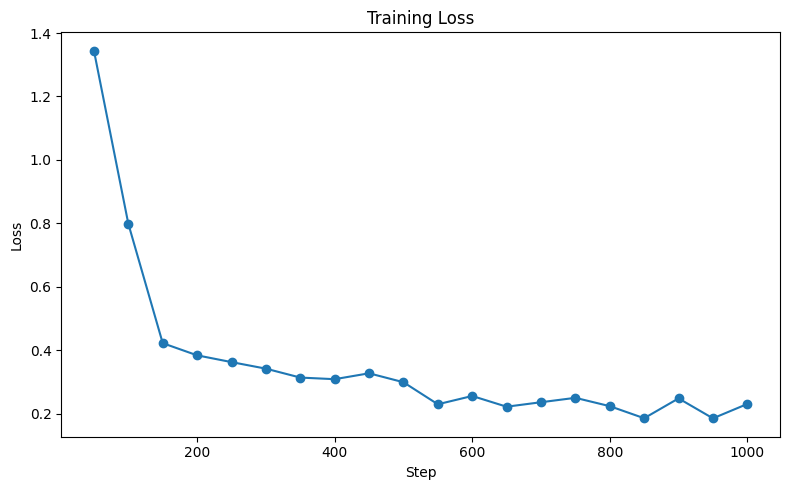

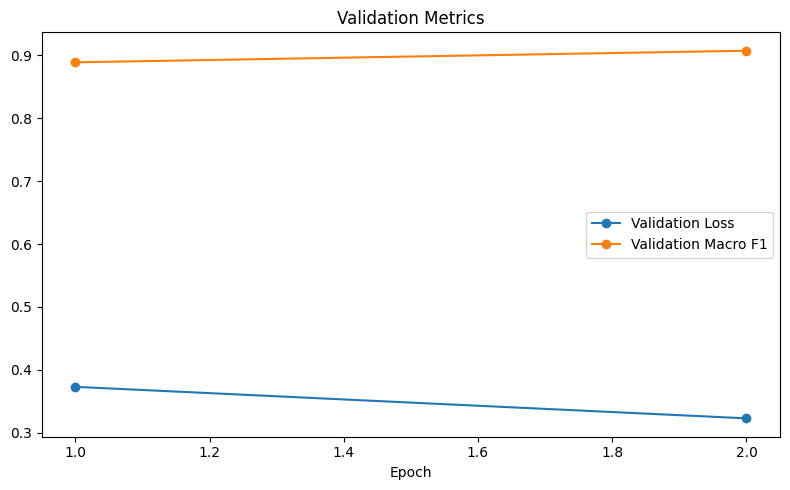

In [27]:
history = pd.DataFrame(trainer.state.log_history)
history.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

display(history.tail())

if "loss" in history.columns:
  train_loss_history = history.dropna(subset=["loss"])
  plt.figure(figsize=(8, 5))
  plt.plot(train_loss_history["step"], train_loss_history["loss"], marker="o")
  plt.title("Training Loss")
  plt.xlabel("Step")
  plt.ylabel("Loss")
  plt.tight_layout()
  plt.savefig(OUTPUT_DIR / "training_loss.png", dpi=150)
  plt.show()

if "eval_loss" in history.columns:
  eval_history = history.dropna(subset=["eval_loss"])
  plt.figure(figsize=(8, 5))
  plt.plot(eval_history["epoch"], eval_history["eval_loss"], marker="o", label="Validation Loss")
  if "eval_macro_f1" in eval_history.columns:
    plt.plot(eval_history["epoch"], eval_history["eval_macro_f1"], marker="o", label="Validation Macro F1")
  plt.title("Validation Metrics")
  plt.xlabel("Epoch")
  plt.legend()
  plt.tight_layout()
  plt.savefig(OUTPUT_DIR / "validation_metrics.png", dpi=150)
  plt.show()

## 13. Error Analysis

A good project does not stop at metrics.

This section inspects wrong predictions, especially high-confidence errors.  
This helps identify where the model still fails.

In [28]:
probabilities = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
confidence = probabilities.max(axis=1)

raw_test_df = pd.DataFrame(test_dataset)

if "text" not in raw_test_df.columns:
  raise ValueError("test_dataset must contain a 'text' column for error analysis. Use ds-based splits, not raw dataset splits.")

error_df = pd.DataFrame({
  "text": raw_test_df["text"],
  "true_label_id": y_true.astype(int),
  "pred_label_id": y_pred.astype(int),
  "true_label": [id2label[int(i)] for i in y_true],
  "predicted_label": [id2label[int(i)] for i in y_pred],
  "confidence": confidence
})

error_df["is_correct"] = error_df["true_label_id"] == error_df["pred_label_id"]

wrong_predictions = error_df[~error_df["is_correct"]].sort_values(
  by="confidence",
  ascending=False
)

error_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
wrong_predictions.to_csv(OUTPUT_DIR / "wrong_predictions.csv", index=False)

print("Total test samples:", len(error_df))
print("Correct predictions:", int(error_df["is_correct"].sum()))
print("Wrong predictions:", len(wrong_predictions))

wrong_predictions.head(10)

Total test samples: 1000
Correct predictions: 909
Wrong predictions: 91


,text,true_label_id,pred_label_id,true_label,predicted_label,confidence,is_correct
611,Special to ESPN.com. It #39;s the age old ques...,2,1,Business,Sports,0.992477,False
229,Another homicide in Holland. It is a sad day....,3,0,Sci/Tech,World,0.986011,False
100,Mars water tops science honours. The discovery...,0,3,World,Sci/Tech,0.982760,False
652,Google #39;s New PC Search Tool Poses Risks. N...,2,3,Business,Sci/Tech,0.982562,False
734,US edge out Brazil for gold. The United States...,0,1,World,Sports,0.980913,False
820,US consumers unaware of spyware. The findings ...,2,3,Business,Sci/Tech,0.980505,False
423,"SBC links e-mail, voice messages, fax. SBC on ...",2,3,Business,Sci/Tech,0.980439,False
974,World's oldest man dies aged 113. The world's ...,0,1,World,Sports,0.979884,False
286,Telescope snaps distant 'planet'. The first di...,0,3,World,Sci/Tech,0.979783,False
624,Football: Brazil legend's UK debut. Brazil foo...,0,1,World,Sports,0.978464,False


In [29]:
print("High-confidence wrong prediction examples:")

for idx, row in wrong_predictions.head(5).iterrows():
  print("=" * 100)
  print(f"True label      : {row['true_label']}")
  print(f"Predicted label : {row['predicted_label']}")
  print(f"Confidence      : {row['confidence']:.4f}")
  print("Text:")
  print(row["text"][:800])

High-confidence wrong prediction examples:
True label      : Business
Predicted label : Sports
Confidence      : 0.9925
Text:
Special to ESPN.com. It #39;s the age old question:  quot;What do you give to the man who #39;s been everything? quot;. Only time will tell whether Phil Knight #39;s retirement will be as long-lived as so many players he paid to endorse Nike.
True label      : Sci/Tech
Predicted label : World
Confidence      : 0.9860
Text:
Another homicide in Holland.  It is a sad day.      In what seems to be another politically inspired homicide in Holland, Dutch filmmaker, and controversial columnist Theo van Gogh was brutally murdered in the streets of Amsterdam this morning.
True label      : World
Predicted label : Sci/Tech
Confidence      : 0.9828
Text:
Mars water tops science honours. The discovery that salty, acidic water once flowed across the surface of Mars has topped a list of the 10 key scientific advances of 2004.
True label      : Business
Predicted label : Sci/T

## 14. Inference Function

This section demonstrates how the fine-tuned model can be used for prediction on new text.

In [30]:
def predict_news_category(text, model, tokenizer, max_length=MAX_LENGTH):
  inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=max_length
  )

  inputs = {key: value.to(device) for key, value in inputs.items()}

  model.eval()
  with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred_id = int(torch.argmax(probs).item())

  return {
    "label_id": pred_id,
    "label": id2label[pred_id],
    "confidence": float(probs[pred_id].item()),
    "probabilities": {
      id2label[i]: float(probs[i].item()) for i in range(len(label_names))
    }
  }

In [31]:
sample_news = [
  "The government announced a new international agreement after a meeting with foreign leaders.",
  "The basketball team won the final match after a dramatic comeback in the last quarter.",
  "Shares of the company increased after the firm reported stronger quarterly earnings.",
  "A new artificial intelligence chip was introduced to improve data center performance."
]

for text in sample_news:
  result = predict_news_category(text, model, tokenizer)
  print("=" * 100)
  print("Text:", text)
  print("Prediction:", result["label"])
  print("Confidence:", round(result["confidence"], 4))
  print("Probabilities:", result["probabilities"])

Text: The government announced a new international agreement after a meeting with foreign leaders.
Prediction: World
Confidence: 0.9909
Probabilities: {'World': 0.9909341335296631, 'Sports': 0.0017958107637241483, 'Business': 0.003985962830483913, 'Sci/Tech': 0.0032840853091329336}
Text: The basketball team won the final match after a dramatic comeback in the last quarter.
Prediction: Sports
Confidence: 0.9802
Probabilities: {'World': 0.010372152552008629, 'Sports': 0.980193555355072, 'Business': 0.004080988001078367, 'Sci/Tech': 0.005353323649615049}
Text: Shares of the company increased after the firm reported stronger quarterly earnings.
Prediction: Business
Confidence: 0.9755
Probabilities: {'World': 0.015390990301966667, 'Sports': 0.0027826433070003986, 'Business': 0.9755090475082397, 'Sci/Tech': 0.006317272316664457}
Text: A new artificial intelligence chip was introduced to improve data center performance.
Prediction: Sci/Tech
Confidence: 0.9805
Probabilities: {'World': 0.006509

## 15. Save Model and Tokenizer

The fine-tuned model is saved locally.

Important: model files are usually large.  
Do not upload model weights to GitHub unless explicitly required.  
The repository should upload notebook, README, reports, requirements, and output summaries.

In [32]:
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print(f"Model and tokenizer saved to: {MODEL_DIR}")
print("Saved files:")
for file in MODEL_DIR.iterdir():
  print("-", file.name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: models/distilbert-ag-news
Saved files:
- tokenizer_config.json
- training_args.bin
- model.safetensors
- tokenizer.json
- config.json


## 16. Conclusion

This notebook completed the full Task 1 workflow:

1. Loaded AG News dataset
2. Performed basic EDA
3. Tokenized text using DistilBERT tokenizer
4. Fine-tuned a BERT-family encoder model
5. Evaluated the model using multiple metrics
6. Created confusion matrix and error analysis
7. Tested inference on new examples
8. Saved model, outputs, and report

This makes the project suitable for GitHub submission as an end-to-end deep learning NLP project.